# Data Preprocessing — Field Asset Health Monitor Project

Stage 1 of the pipeline: load, type, validate, and save the data.
Exploration lives in `02_eda.ipynb`.


### **Dataset introduction:**

The MetroPT-3 dataset was collected to support predictive maintenance, anomaly detection, and remaining-useful-life (RUL) modeling for train compressors. It contains multivariate time-series readings from 15 analogue and digital sensors installed on the Air Production Unit (APU) of a metro train — pressures, motor current, oil temperature, and the electrical signals of the air intake valves — spanning February to August 2020. Sensor events were logged at 1 Hz by an onboard embedded device; a schematic of the APU appears in Figure 4 of the accompanying paper.

**Important caveat about this copy:** the version published on Kaggle is not the full 1 Hz recording. Inspection of the original row index showed it was decimated — every 10th sample kept — yielding an effective ~10-second grid (1,516,948 rows) with jitter of 9–13 s. Values are therefore instantaneous snapshots, not averages: events shorter than ~20 s are invisible, and spectral/vibration features are excluded by data availability. This does not harm the project's goal — leak and temperature failure physics unfold over minutes to days — but every downstream design (feature windows, checks, resampling) assumes the 10 s grid, not 1 Hz.
Ground truth: the dataset carries no label column; four failure events (all air leaks) are documented in the accompanying failure-report table and transcribed, source-verified, into configs/config.yaml.

%autoreload 2 is the magic that makes this workflow pleasant: you develop functions in VSC in the .py file, and the notebook always runs the latest version.

### Setup

In [2]:
# re-imports your src modules on every cell run — edit the .py, rerun the cell, no kernel restart
%load_ext autoreload
%autoreload 2

import pandas as pd
pd.set_option("display.max_colwidth", None)  

In [3]:
from fahm import preprocessing as pp

cfg = pp.load_config("../configs/config.yaml")

## Data overview

In [4]:
data = pp.load_naive(cfg)
display(data.info(memory_usage="deep"))

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 17 columns):
 #   Column           Non-Null Count    Dtype  
---  ------           --------------    -----  
 0   Unnamed: 0       1516948 non-null  int64  
 1   timestamp        1516948 non-null  str    
 2   TP2              1516948 non-null  float64
 3   TP3              1516948 non-null  float64
 4   H1               1516948 non-null  float64
 5   DV_pressure      1516948 non-null  float64
 6   Reservoirs       1516948 non-null  float64
 7   Oil_temperature  1516948 non-null  float64
 8   Motor_current    1516948 non-null  float64
 9   COMP             1516948 non-null  float64
 10  DV_eletric       1516948 non-null  float64
 11  Towers           1516948 non-null  float64
 12  MPG              1516948 non-null  float64
 13  LPS              1516948 non-null  float64
 14  Pressure_switch  1516948 non-null  float64
 15  Oil_level        1516948 non-null  float64
 16  Caudal_impulses  1516948 non-

None

In [5]:
display(data.describe().round(2))
display(data.columns)

,Unnamed: 0,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00,1516948.00
mean,7584735.00,1.37,8.98,7.57,0.06,8.99,62.64,2.05,0.84,0.16,0.92,0.83,0.00,0.99,0.90,0.94
std,4379053.12,3.25,0.64,3.33,0.38,0.64,6.52,2.30,0.37,0.37,0.27,0.37,0.06,0.09,0.29,0.24
min,0.00,-0.03,0.73,-0.04,-0.03,0.71,15.40,0.02,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
25%,3792367.50,-0.01,8.49,8.25,-0.02,8.49,57.78,0.04,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00
50%,7584735.00,-0.01,8.96,8.78,-0.02,8.96,62.70,0.04,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00
75%,11377102.50,-0.01,9.49,9.37,-0.02,9.49,67.25,3.81,1.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00
max,15169470.00,10.68,10.30,10.29,9.84,10.30,89.05,9.30,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00


Index(['Unnamed: 0', 'timestamp', 'TP2', 'TP3', 'H1', 'DV_pressure',
       'Reservoirs', 'Oil_temperature', 'Motor_current', 'COMP', 'DV_eletric',
       'Towers', 'MPG', 'LPS', 'Pressure_switch', 'Oil_level',
       'Caudal_impulses'],
      dtype='str')

In [6]:
display(data.head(10))
display(data.tail(10))

,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1,10,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
2,20,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
3,30,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
4,40,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
5,50,2020-02-01 00:00:49,-0.012,9.306,9.290,-0.024,9.308,53.500,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
6,60,2020-02-01 00:00:59,-0.012,9.296,9.280,-0.024,9.298,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
7,70,2020-02-01 00:01:09,-0.014,9.286,9.270,-0.024,9.286,53.550,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
8,80,2020-02-01 00:01:19,-0.012,9.276,9.258,-0.022,9.276,53.425,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
9,90,2020-02-01 00:01:29,-0.012,9.264,9.248,-0.022,9.264,53.375,0.0400,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


,Unnamed: 0,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
1516938,15169380,2020-09-01 03:58:21,-0.012,8.990,8.974,-0.022,8.992,60.075,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516939,15169390,2020-09-01 03:58:31,-0.012,8.974,8.960,-0.022,8.976,60.150,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516940,15169400,2020-09-01 03:58:40,-0.012,8.960,8.946,-0.020,8.962,59.950,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516941,15169410,2020-09-01 03:58:50,-0.012,8.946,8.932,-0.022,8.948,59.850,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516942,15169420,2020-09-01 03:59:00,-0.012,8.934,8.920,-0.022,8.934,59.775,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516943,15169430,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516944,15169440,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516945,15169450,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516946,15169460,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0
1516947,15169470,2020-09-01 03:59:50,-0.014,8.860,8.848,-0.022,8.864,59.475,0.0425,1.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0


#### how many missing values?

In [7]:
data.isna().sum()

Unnamed: 0         0
timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

**note:** what the raw look shows — Unnamed: 0 (decimation evidence),
        timestamp as string, float64 everywhere, 224.2 MB baseline, no missing

## Cleaning & typing

**Decision:** the decisions (D04-D05): datetime parsing, float64/int8, drop index
        col, canonical order — and why

In [8]:
df = pp.load_raw(cfg)             
display(df.head())                 

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
0,2020-02-01 00:00:00,-0.012,9.358,9.340,-0.024,9.358,53.600,0.0400,1,0,1,1,0,1,1,1
1,2020-02-01 00:00:10,-0.014,9.348,9.332,-0.022,9.348,53.675,0.0400,1,0,1,1,0,1,1,1
2,2020-02-01 00:00:19,-0.012,9.338,9.322,-0.022,9.338,53.600,0.0425,1,0,1,1,0,1,1,1
3,2020-02-01 00:00:29,-0.012,9.328,9.312,-0.022,9.328,53.425,0.0400,1,0,1,1,0,1,1,1
4,2020-02-01 00:00:39,-0.012,9.318,9.302,-0.022,9.318,53.475,0.0400,1,0,1,1,0,1,1,1


In [9]:
display(df.tail())

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
1516943,2020-09-01 03:59:10,-0.014,8.918,8.906,-0.022,8.918,59.675,0.0425,1,0,1,1,0,1,1,1
1516944,2020-09-01 03:59:20,-0.014,8.904,8.888,-0.020,8.904,59.600,0.0450,1,0,1,1,0,1,1,1
1516945,2020-09-01 03:59:30,-0.014,8.890,8.876,-0.022,8.892,59.600,0.0425,1,0,1,1,0,1,1,1
1516946,2020-09-01 03:59:40,-0.012,8.876,8.864,-0.022,8.878,59.550,0.0450,1,0,1,1,0,1,1,1
1516947,2020-09-01 03:59:50,-0.014,8.860,8.848,-0.022,8.864,59.475,0.0425,1,0,1,1,0,1,1,1


In [10]:
display(df.info(memory_usage="deep"))
display(df.describe())

<class 'pandas.DataFrame'>
RangeIndex: 1516948 entries, 0 to 1516947
Data columns (total 16 columns):
 #   Column           Non-Null Count    Dtype         
---  ------           --------------    -----         
 0   timestamp        1516948 non-null  datetime64[us]
 1   TP2              1516948 non-null  float64       
 2   TP3              1516948 non-null  float64       
 3   H1               1516948 non-null  float64       
 4   DV_pressure      1516948 non-null  float64       
 5   Reservoirs       1516948 non-null  float64       
 6   Oil_temperature  1516948 non-null  float64       
 7   Motor_current    1516948 non-null  float64       
 8   COMP             1516948 non-null  int8          
 9   DV_eletric       1516948 non-null  int8          
 10  Towers           1516948 non-null  int8          
 11  MPG              1516948 non-null  int8          
 12  LPS              1516948 non-null  int8          
 13  Pressure_switch  1516948 non-null  int8          
 14  Oil_level    

None

,timestamp,TP2,TP3,H1,DV_pressure,Reservoirs,Oil_temperature,Motor_current,COMP,DV_eletric,Towers,MPG,LPS,Pressure_switch,Oil_level,Caudal_impulses
count,1516948,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06,1.516948e+06
mean,2020-05-16 22:58:36.631517,1.367826e+00,8.984611e+00,7.568155e+00,5.595619e-02,8.985233e+00,6.264418e+01,2.050171e+00,8.369568e-01,1.606106e-01,9.198483e-01,8.326640e-01,3.420025e-03,9.914368e-01,9.041556e-01,9.371066e-01
min,2020-02-01 00:00:00,-3.200000e-02,7.300000e-01,-3.600000e-02,-3.200000e-02,7.120000e-01,1.540000e+01,2.000000e-02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2020-03-23 05:05:04.500000,-1.400000e-02,8.492000e+00,8.254000e+00,-2.200000e-02,8.494000e+00,5.777500e+01,4.000000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
50%,2020-05-17 08:07:06,-1.200000e-02,8.960000e+00,8.784000e+00,-2.000000e-02,8.960000e+00,6.270000e+01,4.500000e-02,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
75%,2020-07-10 03:07:27.500000,-1.000000e-02,9.492000e+00,9.374000e+00,-1.800000e-02,9.492000e+00,6.725000e+01,3.807500e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
max,2020-09-01 03:59:50,1.067600e+01,1.030200e+01,1.028800e+01,9.844000e+00,1.030000e+01,8.905000e+01,9.295000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00
std,NaN,3.250930e+00,6.390951e-01,3.333200e+00,3.824015e-01,6.383070e-01,6.516261e+00,2.302053e+00,3.694052e-01,3.671716e-01,2.715280e-01,3.732757e-01,5.838091e-02,9.214078e-02,2.943779e-01,2.427712e-01


In [11]:
prof = pp.profile(df)
display(f"shape: {prof['shape']}, memory: {prof['memory_mb']} MB")
display(f"time range: {prof['time_range'][0]} → {prof['time_range'][1]}")
display(f"modal interval: {prof['modal_interval']} ({prof['modal_share']:.1%} of steps)")
prof["missing_per_column"]

'shape: (1516948, 16), memory: 109.2 MB'

'time range: 2020-02-01 00:00:00 → 2020-09-01 03:59:50'

'modal interval: 0 days 00:00:10 (88.2% of steps)'

timestamp          0
TP2                0
TP3                0
H1                 0
DV_pressure        0
Reservoirs         0
Oil_temperature    0
Motor_current      0
COMP               0
DV_eletric         0
Towers             0
MPG                0
LPS                0
Pressure_switch    0
Oil_level          0
Caudal_impulses    0
dtype: int64

Work with df after cleaning and removing naive data

In [12]:
del data

**We got:** result 224.2 -> 104.2 MB (2.15x); del data  <- free the memory

## Sampling regularity
Modal interval 10s (~88% of steps), jitter 9–13s; the long tail is the gap inventory (see checks/gaps below).

In [13]:
display(prof["interval_distribution"])

timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
                    ...   
0 days 03:45:10          1
0 days 01:19:09          1
0 days 00:05:41          1
0 days 04:22:23          1
0 days 01:55:04          1
Name: count, Length: 337, dtype: int64

In [14]:
# interval distribution 
display(prof["interval_distribution"].head(10))

timestamp
0 days 00:00:10    1337521
0 days 00:00:09     128277
0 days 00:00:12      38321
0 days 00:00:13       7988
0 days 00:00:11       4471
0 days 00:00:21         10
0 days 00:00:19          5
0 days 00:00:22          4
0 days 00:00:20          3
0 days 00:00:17          3
Name: count, dtype: int64

## Failure windows (ground truth)
Four documented failures — **all air leaks** — transcribed from the failure-report
table in the Kaggle dataset's PDF documentation, source-verified (D07). Two source
quirks recorded as-is: the table numbering reads #1,#1,#3,#4 (second row assumed a
typo for #2), and F2's maintenance date (30 Apr) precedes its failure (30 May) —
likely a typo, transcribed faithfully and flagged.

**Rule (D01-adjacent):** these windows are *evaluation ground truth only* — never
features, never training labels.

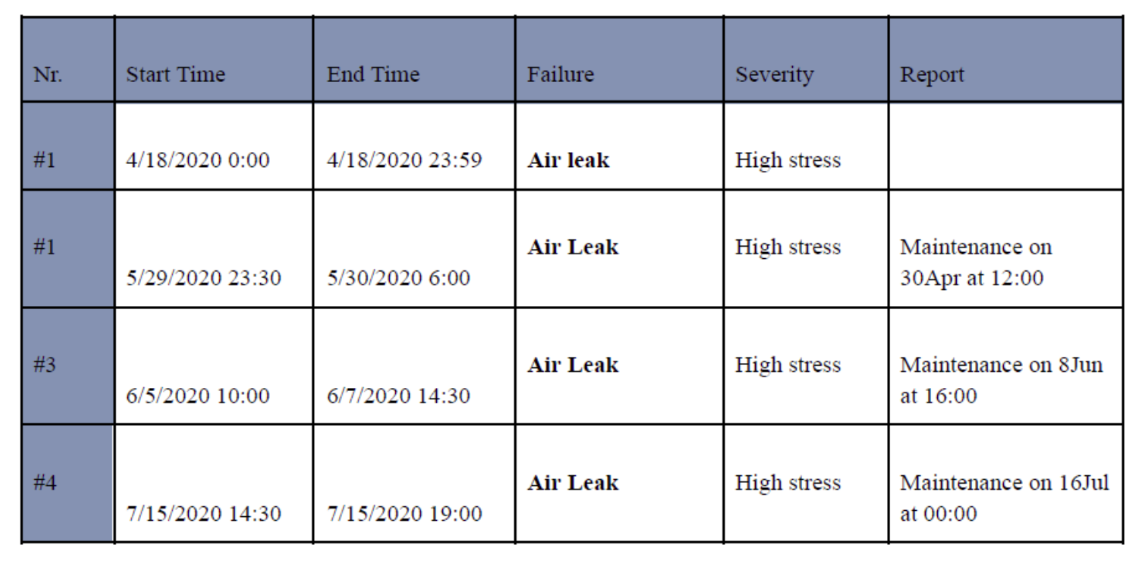

In [15]:
fw = pd.DataFrame(cfg["failure_windows"])
fw

,failure_id,fault_type,start,end,maintenance
0,F1,air_leak,2020-04-18 00:00,2020-04-18 23:59,NaN
1,F2,air_leak,2020-05-29 23:30,2020-05-30 06:00,2020-04-30 12:00
2,F3,air_leak,2020-06-05 10:00,2020-06-07 14:30,2020-06-08 16:00
3,F4,air_leak,2020-07-15 14:30,2020-07-15 19:00,2020-07-16 00:00


#### Consistency checks
`run_checks(df, cfg)` — six checks, thresholds from config (D08), posture per D09.

In [16]:
results = pp.run_checks(df, cfg)
display(results)

,check,passed,detail
0,timestamps_strictly_increasing,True,"0 non-increasing steps in 1,516,947"
1,modal_interval,True,modal 0 days 00:00:10 (88.2% of steps) vs expected 10s
2,digitals_binary,True,all 8 binary
3,tp3_reservoirs_agree,True,mean 0.0019 vs 0.01; max 0.182 vs 0.5
4,valve_antiphase,True,|mean(COMP+DV_eletric)-1| = 0.0024 vs eps 0.02
5,analog_ranges,True,all within configured ranges


#### Recording gaps (step 4)
Inventory of holes > `gap_threshold_seconds`; feeds the D08 threshold revisit, OQ2, and the data profile.

In [17]:
gaps = pp.find_gaps(df, cfg)
gaps.head(10)

,gap_start,gap_end,gap_minutes
618538,2020-04-25 01:10:51,2020-04-27 01:12:49,2881.966667
1055664,2020-06-27 10:53:07,2020-06-28 23:07:43,2174.600000
214850,2020-02-28 23:57:08,2020-03-01 04:00:09,1683.016667
1318888,2020-08-04 07:42:28,2020-08-05 08:23:01,1480.550000
805415,2020-05-24 00:39:23,2020-05-25 01:14:14,1474.850000
1126187,2020-07-07 15:24:51,2020-07-08 15:20:51,1436.000000
1454438,2020-08-22 19:11:44,2020-08-23 18:51:01,1419.283333
708881,2020-05-10 00:31:17,2020-05-10 22:48:58,1337.683333
908125,2020-06-07 14:19:39,2020-06-08 11:48:04,1288.416667
450114,2020-04-01 13:15:40,2020-04-02 09:59:17,1243.616667


In [18]:
fw = pp.build_failure_windows(cfg)
fw

,failure_id,fault_type,start,end,maintenance
0,F1,air_leak,2020-04-18 00:00:00,2020-04-18 23:59:00,NaT
1,F2,air_leak,2020-05-29 23:30:00,2020-05-30 06:00:00,2020-04-30 12:00:00
2,F3,air_leak,2020-06-05 10:00:00,2020-06-07 14:30:00,2020-06-08 16:00:00
3,F4,air_leak,2020-07-15 14:30:00,2020-07-15 19:00:00,2020-07-16 00:00:00


In [27]:
print(f"the amount of gaps in working time is: {len(gaps)}")
print(f"the sum of all the gaps in time is: {gaps['gap_minutes'].sum():,.0f}")
print(f"the minimal gap time is: {gaps['gap_minutes'].min():,.2f}")

the amount of gaps in working time is: 331
the sum of all the gaps in time is: 54,571
the minimal gap time is: 1.73


#### Save processed data (step 6)
Typed, validated table -> reusable file; format decision to be logged.

In [20]:
pp.save_processed(df, cfg)

PosixPath('/home/leoadmin/Documents/GitHub/FAHM_Project/data/processed/sensor_readings.parquet')